# DATASET PREPROCESSING

##### Run Every Session

In [ ]:
import os
import numpy as np
import librosa
from google.colab import drive

# 1. Mount Drive to access your saved .npy files
drive.mount('/content/drive')

# 2. Define your paths so the rest of the notebook knows where to look
DRIVE_SAVE_DIR = '/content/drive/MyDrive/1_Envision/Instrument_Project_Data'
SAMPLE_RATE = 16000
DURATION = 3.0

print("Environment Ready.")

Mounted at /content/drive
Environment Ready.


##### Run once only

In [ ]:
!pip install opendatasets --upgrade -q
import opendatasets as od

dataset_url = 'https://www.kaggle.com/datasets/abdulvahap/music-instrunment-sounds-for-classification'

# This will create a folder named 'music-instrunment-sounds-for-classification'
od.download(dataset_url)

# Note: opendatasets downloads into the current directory.
# We don't need to manually 'unzip' as od.download does it for us.

import os
from tqdm import tqdm

# Update the path to match where opendatasets saved it
DATA_PATH = '/content/music-instrunment-sounds-for-classification/music_dataset'
TARGET_SAMPLES = int(SAMPLE_RATE * DURATION)

# List of instruments
TARGET_INSTRUMENTS = [
    'Acoustic_Guitar', 'Bass_Guitar', 'Electro_Guitar',
    'Violin', 'Mandolin',
    'Drum_set',
    'Piano', 'Keyboard',
    'Trumpet',  'flute',
]

# Each instrument gets its own subfolder of .npy files
AUDIO_SAVE_DIR = os.path.join(DRIVE_SAVE_DIR, 'audio_arrays')
os.makedirs(AUDIO_SAVE_DIR, exist_ok=True)

# We'll build a manifest CSV: filepath -> label
# This is the only thing kept in RAM — tiny
manifest = []

print("\n--- STARTING AUDIO PROCESSING ---")
for instrument_folder in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, instrument_folder)

    if not (os.path.isdir(folder_path) and instrument_folder in TARGET_INSTRUMENTS):
        continue

    # One subfolder per instrument in Drive
    instrument_save_dir = os.path.join(AUDIO_SAVE_DIR, instrument_folder)
    os.makedirs(instrument_save_dir, exist_ok=True)

    print(f"Processing: {instrument_folder}")
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

    for file in tqdm(audio_files):
        file_path = os.path.join(folder_path, file)
        try:
            audio_array, _ = librosa.load(file_path, sr=SAMPLE_RATE)

            # Pad or truncate
            if len(audio_array) > TARGET_SAMPLES:
                audio_array = audio_array[:TARGET_SAMPLES]
            else:
                audio_array = np.pad(audio_array, (0, TARGET_SAMPLES - len(audio_array)), 'constant')

            # Save individual .npy — one file per audio clip
            save_name = os.path.splitext(file)[0] + '.npy'
            save_path = os.path.join(instrument_save_dir, save_name)
            np.save(save_path, audio_array.astype(np.float16))

            # Log to manifest (just strings, no arrays in RAM)
            manifest.append({'path': save_path, 'label': instrument_folder})

        except Exception as e:
            print(f"  Skipped {file}: {e}")
            continue

# Save manifest — this is your master index for everything later
import pandas as pd
manifest_df = pd.DataFrame(manifest)
manifest_path = os.path.join(DRIVE_SAVE_DIR, 'manifest.csv')
manifest_df.to_csv(manifest_path, index=False)

print(f"\nDone! {len(manifest_df)} files saved.")
print(f"Manifest saved to: {manifest_path}")
print(manifest_df.head())

Skipping, found downloaded files in "./music-instrunment-sounds-for-classification" (use force=True to force download)

--- STARTING AUDIO PROCESSING ---
Processing: Acoustic_Guitar


100%|██████████| 3654/3654 [01:10<00:00, 51.80it/s]


Processing: flute


100%|██████████| 3719/3719 [01:11<00:00, 52.20it/s]


Processing: Mandolin


...

Processing: Keyboard


100%|██████████| 2041/2041 [00:39<00:00, 51.81it/s]


Processing: Piano


100%|██████████| 575/575 [02:31<00:00,  3.80it/s]



Done! 22157 files saved.
Manifest saved to: /content/drive/MyDrive/1_Envision/Instrument_Project_Data/manifest.csv
                                                path            label
0  /content/drive/MyDrive/1_Envision/Instrument_P...  Acoustic_Guitar
1  /content/drive/MyDrive/1_Envision/Instrument_P...  Acoustic_Guitar
2  /content/drive/MyDrive/1_Envision/Instrument_P...  Acoustic_Guitar
3  /content/drive/MyDrive/1_Envision/Instrument_P...  Acoustic_Guitar
4  /content/drive/MyDrive/1_Envision/Instrument_P...  Acoustic_Guitar


##### Run Every Session

In [ ]:
import pandas as pd

# Load the manifest — your single source of truth
manifest_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'manifest.csv'))

X = manifest_df['path'].values   # array of .npy file paths
y = manifest_df['label'].values  # array of string labels

print(f"Manifest Loaded: {len(manifest_df)} samples across {manifest_df['label'].nunique()} instruments.")
print(manifest_df['label'].value_counts())

Manifest Loaded: 22157 samples across 10 instruments.
label
flute              3719
Acoustic_Guitar    3654
Drum_set           3648
Bass_Guitar        3613
Mandolin           2458
Keyboard           2041
Electro_Guitar     1316
Violin              630
Piano               575
Trumpet             503
Name: count, dtype: int64


# TRAIN-TEST SPLIT

##### Run every session

In [ ]:
import pandas as pd
import numpy as np
import os

# 1. Load the manifest
manifest_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'manifest.csv'))

# 2. Extract the numeric part of the filename so we can sort properly
def get_file_num(path):
    filename = os.path.basename(path)  # e.g., '100.npy'
    num_str = os.path.splitext(filename)[0]  # e.g., '100'
    try:
        return int(num_str)
    except ValueError:
        return 0  # Fallback if something is named weirdly

manifest_df['file_num'] = manifest_df['path'].apply(get_file_num)

# 3. Sort chronologically by instrument, then by file number
manifest_df = manifest_df.sort_values(by=['label', 'file_num'])

# 4. Perform the Sequential 80/20 Split (without shuffling)
train_list = []
test_list = []

for instrument in manifest_df['label'].unique():
    # Get all files for this specific instrument
    subset = manifest_df[manifest_df['label'] == instrument]

    # Find the 80% cutoff index
    split_idx = int(len(subset) * 0.8)

    # First 80% goes to train, last 20% goes to test
    train_subset = subset.iloc[:split_idx].copy()
    train_subset['split'] = 'train'

    test_subset = subset.iloc[split_idx:].copy()
    test_subset['split'] = 'test'

    train_list.append(train_subset)
    test_list.append(test_subset)

# Combine back into a single dataframe
split_df = pd.concat(train_list + test_list, ignore_index=True)

# Drop the temporary 'file_num' column
split_df = split_df.drop('file_num', axis=1)

# 5. Save the split manifest to Drive
split_manifest_path = os.path.join(DRIVE_SAVE_DIR, 'manifest_split.csv')
split_df.to_csv(split_manifest_path, index=False)

# 6. Verification
X_train = split_df[split_df['split'] == 'train']['path'].values
X_test  = split_df[split_df['split'] == 'test']['path'].values

print("--- SEQUENTIAL SPLIT COMPLETE ---")
print(f"Training set: {len(X_train)} samples")
print(f"Testing set:  {len(X_test)} samples\n")

--- SEQUENTIAL SPLIT COMPLETE ---
Training set: 17722 samples
Testing set:  4435 samples



##### Run every session

In [ ]:
split_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'manifest_split.csv'))
X_train = split_df[split_df['split'] == 'train']['path'].values
X_test  = split_df[split_df['split'] == 'test']['path'].values
y_train = split_df[split_df['split'] == 'train']['label'].values
y_test  = split_df[split_df['split'] == 'test']['label'].values

# TIME DOMAIN FEATURE EXTRACTION

##### Run only once

In [ ]:
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import os

# ==========================================
# 1. DEFINE THE EXTRACTION FUNCTION
# ==========================================
def extract_time_features(audio_array, sr=16000):
    frame_length = 512
    hop_length = 512

    rms = librosa.feature.rms(y=audio_array, frame_length=frame_length, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(y=audio_array, frame_length=frame_length, hop_length=hop_length)[0]

    features = {
        'rms_mean': np.mean(rms),
        'rms_std': np.std(rms),
        'zcr_mean': np.mean(zcr),
        'zcr_std': np.std(zcr)
    }

    return features

# ==========================================
# 2. PROCESS ENTIRE DATASETS
# ==========================================
def build_time_feature_table(X_paths, y_data):
    feature_list = []
    for i in tqdm(range(len(X_paths))):
        audio = np.load(X_paths[i])
        feats = extract_time_features(audio, sr=SAMPLE_RATE)
        feats['target_instrument'] = y_data[i]
        feature_list.append(feats)

    return pd.DataFrame(feature_list)

print("\n--- Extracting Features for Training Set ---")
time_train_df = build_time_feature_table(X_train, y_train)

print("\n--- Extracting Features for Testing Set ---")
time_test_df = build_time_feature_table(X_test, y_test)

# ==========================================
# 3. SAVE TABLES TO GOOGLE DRIVE
# ==========================================
time_train_df.to_csv(os.path.join(DRIVE_SAVE_DIR, 'train_time_features.csv'), index=False)
time_test_df.to_csv(os.path.join(DRIVE_SAVE_DIR, 'test_time_features.csv'), index=False)

print(f"\nSuccess! Feature tables saved to: {DRIVE_SAVE_DIR}")
print(time_train_df.head())


--- Extracting Features for Training Set ---


100%|██████████| 17722/17722 [01:46<00:00, 166.29it/s]



--- Extracting Features for Testing Set ---


100%|██████████| 4435/4435 [00:28<00:00, 157.18it/s]



Success! Feature tables saved to: /content/drive/MyDrive/1_Envision/Instrument_Project_Data
   rms_mean   rms_std  zcr_mean   zcr_std target_instrument
0  0.087690  0.081314  0.074759  0.067725   Acoustic_Guitar
1  0.132608  0.057303  0.037442  0.013507   Acoustic_Guitar
2  0.121506  0.044609  0.046522  0.019291   Acoustic_Guitar
3  0.159802  0.066057  0.041930  0.021512   Acoustic_Guitar
4  0.146385  0.051780  0.039707  0.020761   Acoustic_Guitar


##### Run every session

In [ ]:
import pandas as pd
import os

# Load the CSV files into Pandas DataFrames
time_train_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'train_time_features.csv'))
time_test_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'test_time_features.csv'))

# Separate the Features (X) from the Target Labels (y)
X_train_time = time_train_df.drop('target_instrument', axis=1)
y_train_time = time_train_df['target_instrument']

X_test_time = time_test_df.drop('target_instrument', axis=1)
y_test_time = time_test_df['target_instrument']

print(f"Time-Domain Training Data Loaded: {X_train_time.shape}")
print(f"Time-Domain Testing Data Loaded: {X_test_time.shape}")

Time-Domain Training Data Loaded: (17722, 4)
Time-Domain Testing Data Loaded: (4435, 4)


# Training the ML Models - SVM, kNN and RF

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Initialize the Models
# We use 'scaled' or default hyperparameters as a baseline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

time_models = {
    "Support Vector Machine": Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=1.0, probability=True))]),
    "k-Nearest Neighbors":    Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))]),
    "Random Forest":          RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
}

# 2. Dictionary to store results
time_results = {}

print("--- TRAINING MODELS ON TIME-DOMAIN FEATURES ---")

for name, model in time_models.items():
    # Train the model
    model.fit(X_train_time, y_train_time)

    # Make predictions
    predictions = model.predict(X_test_time)

    # Calculate Accuracy
    acc = accuracy_score(y_test_time, predictions)
    time_results[name] = acc

    # Calculate Training Score
    train_acc = model.score(X_train_time, y_train_time)

    # Calculate Testing Score
    test_acc = model.score(X_test_time, y_test_time)

    print(f"Training Accuracy: {train_acc * 100:.2f}%")
    print(f"Testing Accuracy: {test_acc * 100:.2f}%")

    print(f"Finished: {name} | Accuracy: {acc:.2%}")

# 3. Display the Comparison Table
time_comparison_df = pd.DataFrame(list(time_results.items()), columns=['Model', 'Accuracy'])
print("\n--- FINAL COMPARISON ---")
print(time_comparison_df.sort_values(by='Accuracy', ascending=False))

--- TRAINING MODELS ON TIME-DOMAIN FEATURES ---
Training Accuracy: 85.39%
Testing Accuracy: 86.61%
Finished: Support Vector Machine | Accuracy: 86.61%
Training Accuracy: 90.76%
Testing Accuracy: 89.43%
Finished: k-Nearest Neighbors | Accuracy: 89.43%
Training Accuracy: 90.62%
Testing Accuracy: 89.31%
Finished: Random Forest | Accuracy: 89.31%

--- FINAL COMPARISON ---
                    Model  Accuracy
1     k-Nearest Neighbors  0.894250
2           Random Forest  0.893123
0  Support Vector Machine  0.866065


### Evaluation

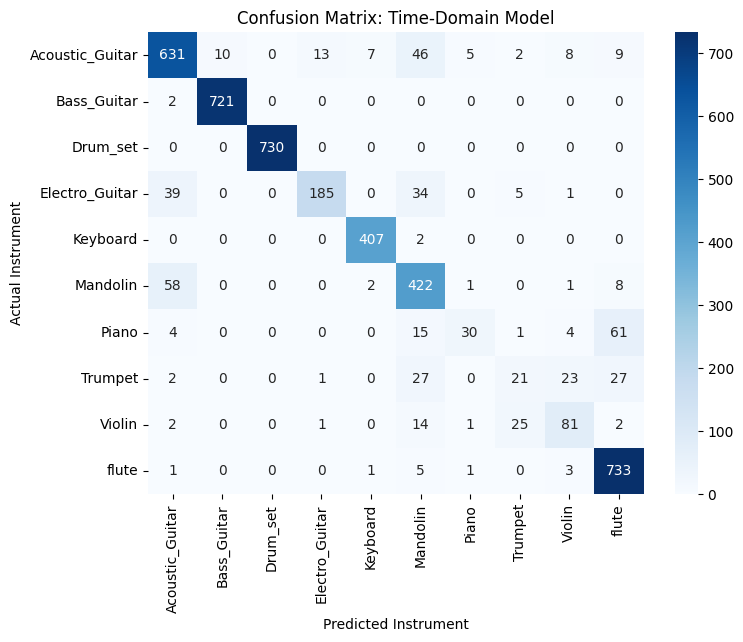

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Replace 'Random Forest' with your highest performing model from Block 1
time_best_model = time_models["Random Forest"]
y_pred_time = time_best_model.predict(X_test_time)

# Create Confusion Matrix
plt.figure(figsize=(8, 6))

labels = sorted(y_test_time.unique())
cm_time = confusion_matrix(y_test_time, y_pred_time, labels=labels)
sns.heatmap(cm_time, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix: Time-Domain Model')
plt.ylabel('Actual Instrument')
plt.xlabel('Predicted Instrument')
plt.show()

# FREQUENCY DOMAIN FEATURE EXTRACTION

##### Run only once

In [ ]:
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import os

# ==========================================
# 1. DEFINE THE EXTRACTION FUNCTION
# ==========================================
def extract_freq_features(audio_array, sr=16000):

    # Standard hop length for consistency
    hop_length = 512

    # --- Frequency Domain ---
    # Spectral Centroid (Brightness)
    sc = librosa.feature.spectral_centroid(y=audio_array, sr=sr, n_fft=1024, hop_length=hop_length)[0]
    # Spectral Bandwidth (Spread)
    sb = librosa.feature.spectral_bandwidth(y=audio_array, sr=sr, n_fft=1024, hop_length=hop_length)[0]
    # Spectral Flux (Rate of spectral change)
    S = np.abs(librosa.stft(audio_array, n_fft=1024, hop_length=hop_length))
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0))

    return {
        'centroid_mean': np.mean(sc), 'centroid_std': np.std(sc),
        'bandwidth_mean': np.mean(sb), 'bandwidth_std': np.std(sb),
        'flux_mean': np.mean(flux), 'flux_std': np.std(flux)
    }

# ==========================================
# 2. PROCESSING LOOP
# ==========================================
def build_freq_feature_table(X_paths, y_data):
  feature_list = []
  for i in tqdm(range(len(X_paths))):
      audio = np.load(X_paths[i])
      feats = extract_freq_features(audio, sr=SAMPLE_RATE)
      feats['target_instrument'] = y_data[i]
      feature_list.append(feats)

  return pd.DataFrame(feature_list)

print("\n--- Processing Training Set (Frequency) ---")
freq_train_df = build_freq_feature_table(X_train, y_train)

print("\n--- Processing Testing Set (Frequency) ---")
freq_test_df = build_freq_feature_table(X_test, y_test)

# ==========================================
# 3. SAVE TABLES TO DRIVE
# ==========================================
freq_train_df.to_csv(os.path.join(DRIVE_SAVE_DIR, 'train_freq_features.csv'), index=False)
freq_test_df.to_csv(os.path.join(DRIVE_SAVE_DIR, 'test_freq_features.csv'), index=False)

print(f"\nSuccess! Frequency feature tables saved to: {DRIVE_SAVE_DIR}")
print(freq_train_df.head())


--- Processing Training Set (Frequency) ---


100%|██████████| 17722/17722 [04:58<00:00, 59.32it/s]



--- Processing Testing Set (Frequency) ---


100%|██████████| 4435/4435 [01:15<00:00, 58.73it/s]



Success! Frequency feature tables saved to: /content/drive/MyDrive/1_Envision/Instrument_Project_Data
   centroid_mean  centroid_std  bandwidth_mean  bandwidth_std  flux_mean  \
0     901.645588    734.506312     1060.049217     511.286539  12.744304   
1     633.710221    173.126043      988.468431     243.477499  18.119480   
2     685.434690    204.580828     1062.333105     276.077400  16.964228   
3     657.569783    288.058821      956.753089     270.350455  21.761518   
4     601.300024    200.064952      952.272081     269.892547  20.196388   

    flux_std target_instrument  
0  14.725796   Acoustic_Guitar  
1  17.891230   Acoustic_Guitar  
2  10.749094   Acoustic_Guitar  
3  19.999584   Acoustic_Guitar  
4  14.897068   Acoustic_Guitar  


##### Run every session

In [ ]:
# Load the pre-processed Frequency data
freq_train_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'train_freq_features.csv'))
freq_test_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'test_freq_features.csv'))

# Separate Features (X) from Target (y)
X_train_freq = freq_train_df.drop('target_instrument', axis=1)
y_train_freq = freq_train_df['target_instrument']

X_test_freq = freq_test_df.drop('target_instrument', axis=1)
y_test_freq = freq_test_df['target_instrument']

print(f"Freq-Domain Training Data Loaded: {X_train_freq.shape}")
print(f"Freq-Domain Testing Data Loaded: {X_test_freq.shape}")

Freq-Domain Training Data Loaded: (17722, 6)
Freq-Domain Testing Data Loaded: (4435, 6)


# TRAINING THE ML MODELS - SVM, kNN AND RF

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Initialize the Models
# We use 'scaled' or default hyperparameters as a baseline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

freq_models = {
    "Support Vector Machine": Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=1.0, probability=True))]),
    "k-Nearest Neighbors":    Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))]),
    "Random Forest":          RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
}

# 2. Dictionary to store results
freq_results = {}

print("--- TRAINING MODELS ON FREQUENCY-DOMAIN FEATURES ---")

for name, model in freq_models.items():
    # Train the model
    model.fit(X_train_freq, y_train_freq)

    # Make predictions
    predictions = model.predict(X_test_freq)

    # Calculate Accuracy
    acc = accuracy_score(y_test_freq, predictions)
    freq_results[name] = acc

    print(f"Finished: {name} | Accuracy: {acc:.2%}")

# 3. Display the Comparison Table
freq_comparison_df = pd.DataFrame(list(freq_results.items()), columns=['Model', 'Accuracy'])
print("\n--- FINAL COMPARISON ---")
print(freq_comparison_df.sort_values(by='Accuracy', ascending=False))

--- TRAINING MODELS ON FREQUENCY-DOMAIN FEATURES ---
Finished: Support Vector Machine | Accuracy: 92.47%
Finished: k-Nearest Neighbors | Accuracy: 93.89%
Finished: Random Forest | Accuracy: 92.74%

--- FINAL COMPARISON ---
                    Model  Accuracy
1     k-Nearest Neighbors  0.938895
2           Random Forest  0.927396
0  Support Vector Machine  0.924690


### Evaluation

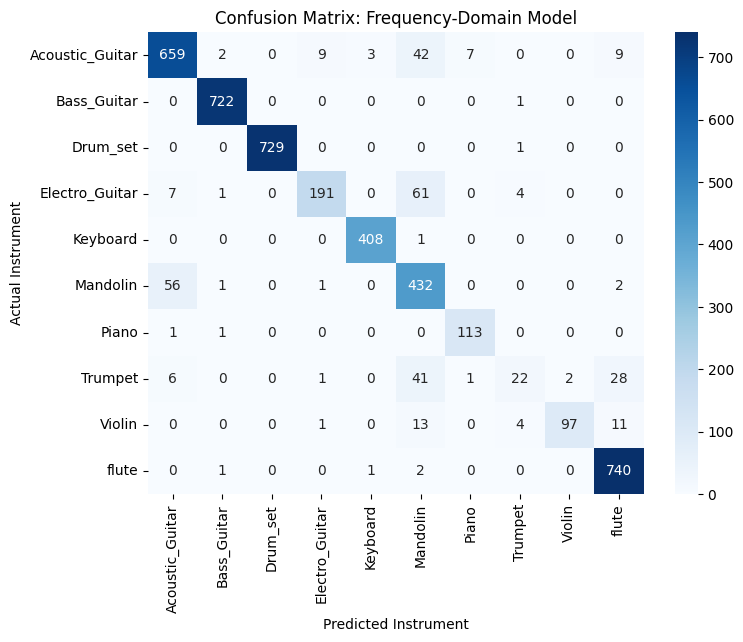

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Replace 'Random Forest' with your highest performing model from Block 1
freq_best_model = freq_models["Random Forest"]
y_pred_freq = freq_best_model.predict(X_test_freq)

# Create Confusion Matrix
plt.figure(figsize=(8, 6))

labels = sorted(y_test_freq.unique())
cm_freq = confusion_matrix(y_test_freq, y_pred_freq, labels=labels)
sns.heatmap(cm_freq, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix: Frequency-Domain Model')
plt.ylabel('Actual Instrument')
plt.xlabel('Predicted Instrument')
plt.show()

# MFCCs

##### Run only once

In [ ]:
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import os
from joblib import Parallel, delayed

# ==========================================
# 3. DEFINE THE EXTRACTION FUNCTION
# ==========================================
def extract_mfcc_features(audio_array, sr=16000):
    hop_length = 512
    mfccs = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=13, hop_length=hop_length)

    features = {}
    for i in range(13):
        features[f'mfcc_{i+1}_mean'] = np.mean(mfccs[i])
        features[f'mfcc_{i+1}_std'] = np.std(mfccs[i])

    return features

# ==========================================
# 4. PROCESSING LOOP (MULTI-CORE OPTIMIZED)
# ==========================================
def process_single_file(filepath, label):
    # Now loading from lightning-fast local storage
    audio = np.load(filepath)
    feats = extract_mfcc_features(audio, sr=16000)
    feats['target_instrument'] = label
    return feats

def build_mfcc_feature_table_fast(X_paths, y_data):
    print(f"Extracting features across {os.cpu_count()} CPU cores...")
    results = Parallel(n_jobs=-1)(
        delayed(process_single_file)(X_paths[i], y_data[i])
        for i in tqdm(range(len(X_paths)))
    )
    return pd.DataFrame(results)

print("\n--- Processing Training Set (MFCC) ---")
mfcc_train_df = build_mfcc_feature_table_fast(X_train, y_train)

print("\n--- Processing Testing Set (MFCC) ---")
mfcc_test_df = build_mfcc_feature_table_fast(X_test, y_test)

# ==========================================
# 5. SAVE TABLES BACK TO DRIVE
# ==========================================
mfcc_train_df.to_csv(os.path.join(DRIVE_SAVE_DIR, 'train_mfcc_features.csv'), index=False)
mfcc_test_df.to_csv(os.path.join(DRIVE_SAVE_DIR, 'test_mfcc_features.csv'), index=False)

print(f"\nSuccess! MFCC feature tables saved to: {DRIVE_SAVE_DIR}")



--- Processing Training Set (MFCC) ---
Extracting features across 2 CPU cores...


100%|██████████| 17722/17722 [04:12<00:00, 70.07it/s]



--- Processing Testing Set (MFCC) ---
Extracting features across 2 CPU cores...


100%|██████████| 4435/4435 [00:59<00:00, 74.60it/s]



Success! MFCC feature tables saved to: /content/drive/MyDrive/1_Envision/Instrument_Project_Data


##### Run every session

MFCC Training Data Loaded: (17722, 26)
MFCC Testing Data Loaded: (4435, 26)
--- TRAINING MODELS ON MFCC FEATURES ---
Finished: Support Vector Machine | Accuracy: 97.43%
Finished: k-Nearest Neighbors | Accuracy: 96.28%
Finished: Random Forest | Accuracy: 97.59%

--- FINAL COMPARISON (MFCC) ---
                    Model  Accuracy
2           Random Forest  0.975874
0  Support Vector Machine  0.974295
1     k-Nearest Neighbors  0.962796


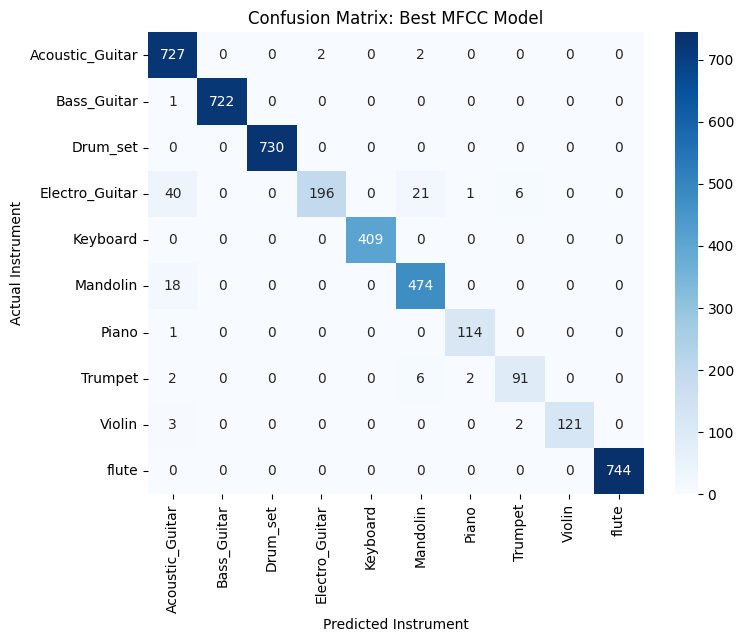

In [ ]:
import pandas as pd
import os

# Load the pre-processed MFCC data
mfcc_train_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'train_mfcc_features.csv'))
mfcc_test_df = pd.read_csv(os.path.join(DRIVE_SAVE_DIR, 'test_mfcc_features.csv'))

# Separate Features (X) from Target (y)
X_train_mfcc = mfcc_train_df.drop('target_instrument', axis=1)
y_train_mfcc = mfcc_train_df['target_instrument']

X_test_mfcc = mfcc_test_df.drop('target_instrument', axis=1)
y_test_mfcc = mfcc_test_df['target_instrument']

print(f"MFCC Training Data Loaded: {X_train_mfcc.shape}")
print(f"MFCC Testing Data Loaded: {X_test_mfcc.shape}")


# TRAINING THE ML MODELS - SVM, kNN AND RF (MFCC)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Initialize the Models
mfcc_models = {
    "Support Vector Machine": Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=1.0, probability=True))]),
    "k-Nearest Neighbors":    Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))]),
    "Random Forest":          RandomForestClassifier(n_estimators=100, random_state=42)
}

# 2. Dictionary to store results
mfcc_results = {}

print("--- TRAINING MODELS ON MFCC FEATURES ---")

for name, model in mfcc_models.items():
    # Train the model
    model.fit(X_train_mfcc, y_train_mfcc)

    # Make predictions
    predictions = model.predict(X_test_mfcc)

    # Calculate Accuracy
    acc = accuracy_score(y_test_mfcc, predictions)
    mfcc_results[name] = acc

    print(f"Finished: {name} | Accuracy: {acc:.2%}")

# 3. Display the Comparison Table
mfcc_comparison_df = pd.DataFrame(list(mfcc_results.items()), columns=['Model', 'Accuracy'])
print("\n--- FINAL COMPARISON (MFCC) ---")
print(mfcc_comparison_df.sort_values(by='Accuracy', ascending=False))


### Evaluation (MFCC)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assume Random Forest is consistently strong, or replace with highest performing model
mfcc_best_model = mfcc_models["Random Forest"]
y_pred_mfcc = mfcc_best_model.predict(X_test_mfcc)

# Create Confusion Matrix
plt.figure(figsize=(8, 6))

labels = sorted(y_test_mfcc.unique())
cm_mfcc = confusion_matrix(y_test_mfcc, y_pred_mfcc, labels=labels)
sns.heatmap(cm_mfcc, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix: Best MFCC Model')
plt.ylabel('Actual Instrument')
plt.xlabel('Predicted Instrument')
plt.show()

## Model Results


In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 0. REDEFINE FEATURE EXTRACTION FUNCTIONS
# ==========================================
def extract_time_features(audio, sr):
    rms = librosa.feature.rms(y=audio)[0]
    zcr = librosa.feature.zero_crossing_rate(y=audio)[0]
    return {
        'rms_mean': np.mean(rms), 'rms_std': np.std(rms),
        'zcr_mean': np.mean(zcr), 'zcr_std': np.std(zcr)
    }

def extract_freq_features(audio, sr):
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0]
    flux = librosa.onset.onset_strength(y=audio, sr=sr)
    return {
        'centroid_mean': np.mean(centroid), 'centroid_std': np.std(centroid),
        'bandwidth_mean': np.mean(bandwidth), 'bandwidth_std': np.std(bandwidth),
        'flux_mean': np.mean(flux), 'flux_std': np.std(flux)
    }

def extract_mfcc_features(audio, sr):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_dict = {}
    for i in range(13):
        mfcc_dict[f'mfcc_{i+1}_mean'] = np.mean(mfccs[i])
        mfcc_dict[f'mfcc_{i+1}_std'] = np.std(mfccs[i])
    return mfcc_dict

# ==========================================
# 1. COMBINE TRAINING DATA & TRAIN MODEL
# ==========================================
print("--- Training Combined Model (Random Forest) ---")
X_train_combined = pd.concat([X_train_time, X_train_freq, X_train_mfcc], axis=1)
y_train_combined = y_train_time

combined_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=67, random_state=42))
])
combined_model.fit(X_train_combined, y_train_combined)
print("Model trained successfully.\n")

# ==========================================
# 2. PROCESS LOCAL AUDIO FILES
# ==========================================
test_folders = ['Drums', 'eguitar', 'bguitar', 'mandolin', 'flute', 'violin', 'trumpet', 'piano']
base_path = '/content/'

folder_to_target = {
    'Drums': 'Drum_set',
    'violin': 'Violin',
    'mandolin': 'Mandolin',
    'flute': 'flute',
    'trumpet': 'Trumpet',
    'piano': 'Piano'
}
guitar_classes = ['Acoustic_Guitar', 'Bass_Guitar', 'Electro_Guitar']

test_features = []
test_labels = []

print("--- Extracting Features from Local Audio Files ---")
for folder in test_folders:
    folder_path = os.path.join(base_path, folder)
    if not os.path.exists(folder_path):
        continue

    audio_files = [f for f in os.listdir(folder_path) if f.endswith(('.mp3', '.wav', '.ogg'))]

    for file in audio_files:
        file_path = os.path.join(folder_path, file)
        try:
            # Load audio
            audio, _ = librosa.load(file_path, sr=16000)

            # --- THE FIX: Strip silence, do NOT pad or reflect ---
            # top_db=30 means anything quieter than 30dB below peak is considered silence
            audio_trimmed, _ = librosa.effects.trim(audio, top_db=30)

            # If trimming removed everything (file was just noise), fallback to original
            if len(audio_trimmed) > 0:
                audio = audio_trimmed

            # Extract features directly from the natural length of the sound
            t_feats = extract_time_features(audio, sr=16000)
            f_feats = extract_freq_features(audio, sr=16000)
            m_feats = extract_mfcc_features(audio, sr=16000)

            combined_feats = {**t_feats, **f_feats, **m_feats}
            test_features.append(combined_feats)
            test_labels.append(folder)

        except Exception as e:
            print(f"Failed to process {file}: {e}")

if test_features:
    # ==========================================
    # 3. ALIGN DATA & PREDICT
    # ==========================================
    X_test_local = pd.DataFrame(test_features)
    X_test_local = X_test_local[X_train_combined.columns]

    predictions = combined_model.predict(X_test_local)
    probabilities = combined_model.predict_proba(X_test_local)
    model_classes = combined_model.classes_

    # ==========================================
    # 4. EVALUATE WITH CUSTOM LOGIC
    # ==========================================
    print("\n--- FINAL EVALUATION REPORT ---")
    results = {f: {'correct': 0, 'total': 0, 'probs': []} for f in test_folders}
    total_correct = 0
    total_samples = len(X_test_local)

    for i in range(total_samples):
        folder = test_labels[i]
        pred = predictions[i]
        probs = probabilities[i]

        results[folder]['total'] += 1
        results[folder]['probs'].append(probs)

        is_correct = False

        if folder in ['eguitar', 'bguitar']:
            if pred in guitar_classes:
                is_correct = True
        else:
            if pred == folder_to_target.get(folder):
                is_correct = True

        if is_correct:
            results[folder]['correct'] += 1
            total_correct += 1

    print(f"OVERALL ACCURACY: {(total_correct / total_samples) * 100:.2f}%\n")

    for folder in test_folders:
        data = results[folder]
        if data['total'] == 0: continue

        acc = (data['correct'] / data['total']) * 100
        print(f"Folder: {folder} | Accuracy: {acc:.2f}% ({data['correct']}/{data['total']})")

        if acc < 50.0:
            avg_probs = np.mean(data['probs'], axis=0)
            top_idx = np.argsort(avg_probs)[::-1]

            print(f"  [!] Accuracy below 50%. Top average model confidences:")
            print(f"      1st Guess: {model_classes[top_idx[0]]} ({avg_probs[top_idx[0]]*100:.1f}%)")
            print(f"      2nd Guess: {model_classes[top_idx[1]]} ({avg_probs[top_idx[1]]*100:.1f}%)")
            print(f"      3rd Guess: {model_classes[top_idx[2]]} ({avg_probs[top_idx[2]]*100:.1f}%)")
        print("-" * 50)

--- Training Combined Model (Random Forest) ---
Model trained successfully.

--- Extracting Features from Local Audio Files ---

--- FINAL EVALUATION REPORT ---
OVERALL ACCURACY: 42.86%



###### Cleanup

In [ ]:
import os
correct_dir = '/content/drive/MyDrive/1_Envision/Instrument_Project_Data/audio_arrays'

for folder in os.listdir(correct_dir):
    folder_path = os.path.join(correct_dir, folder)
    if os.path.isdir(folder_path):
        print(f"Folder {folder}: {len(os.listdir(folder_path))} files")

Folder flute: 3719 files
Folder Keyboard: 2041 files
Folder Banjo: 2998 files
Folder Bass_Guitar: 3613 files
Folder Mandolin: 2458 files
Folder Trumpet: 503 files
Folder Cymbals: 208 files
Folder Piano: 575 files
Folder Tambourine: 558 files
Folder Violin: 630 files
Folder Ukulele: 790 files
Folder Electro_Guitar: 1316 files
Folder Harmonium: 1314 files
Folder Acoustic_Guitar: 3654 files
Folder Organ: 1442 files
Folder Harmonica: 131 files
Folder Clarinet: 634 files
Folder Trombone: 2965 files
Folder Drum_set: 3648 files


In [ ]:
import os
from tqdm import tqdm

# 1. The Root path
root_path = '/content/drive/MyDrive'

# 2. Get list of all .npy files sitting DIRECTLY in MyDrive
# This will NOT look inside your subfolders, so your processed data is safe.
floating_files = [f for f in os.listdir(root_path) if f.endswith('.npy')]

print(f"Detected {len(floating_files)} floating files in Root.")
confirm = input("Are you sure you want to delete these? (y/n): ")

if confirm.lower() == 'y':
    for file in tqdm(floating_files):
        file_path = os.path.join(root_path, file)
        try:
            os.remove(file_path)
        except Exception as e:
            print(f"Error deleting {file}: {e}")
    print("\nRoot Drive cleaned successfully.")
else:
    print("Cleanup cancelled.")

Detected 0 floating files in Root.
Are you sure you want to delete these? (y/n): y


0it [00:00, ?it/s]


Root Drive cleaned successfully.
